In [ ]:
path_to_data = 'store_validate_neumann_fulldepth_01mm'
import numpy as np
import os
import matplotlib.pyplot as plt
from matplotlib import patches
import mplhep as hep
hep.style.use('CMS')

paths_near shape: (40, 40, 9000, 3)
path position in y: [ 0.05197474  1.82171715 10.        ]
path position in y: [ 0.15875084  1.82166956 10.        ]
path position in y: [ 0.26541585  1.82158532 10.        ]
path position in y: [ 0.37190771  1.82145795 10.        ]
path position in y: [ 0.47815554  1.82127745 10.        ]
path position in y: [ 0.5840759   1.82102921 10.        ]
path position in y: [ 0.68956827  1.82069338 10.        ]
path position in y: [ 0.79451009  1.82024119 10.        ]
path position in y: [ 0.89875097  1.81963427 10.        ]
path position in y: [ 1.00210584  1.81882495 10.        ]
path position in y: [ 1.10435037  1.81776434 10.        ]
path position in y: [ 1.20522114  1.81640409 10.        ]
path position in y: [ 1.30437647  1.81472025 10.        ]
path position in y: [ 1.40135688  1.81275447 10.        ]
path position in y: [ 1.4954528   1.81067387 10.        ]
path position in y: [ 1.58543887  1.8088622  10.        ]
path position in y: [ 1.663081    1.

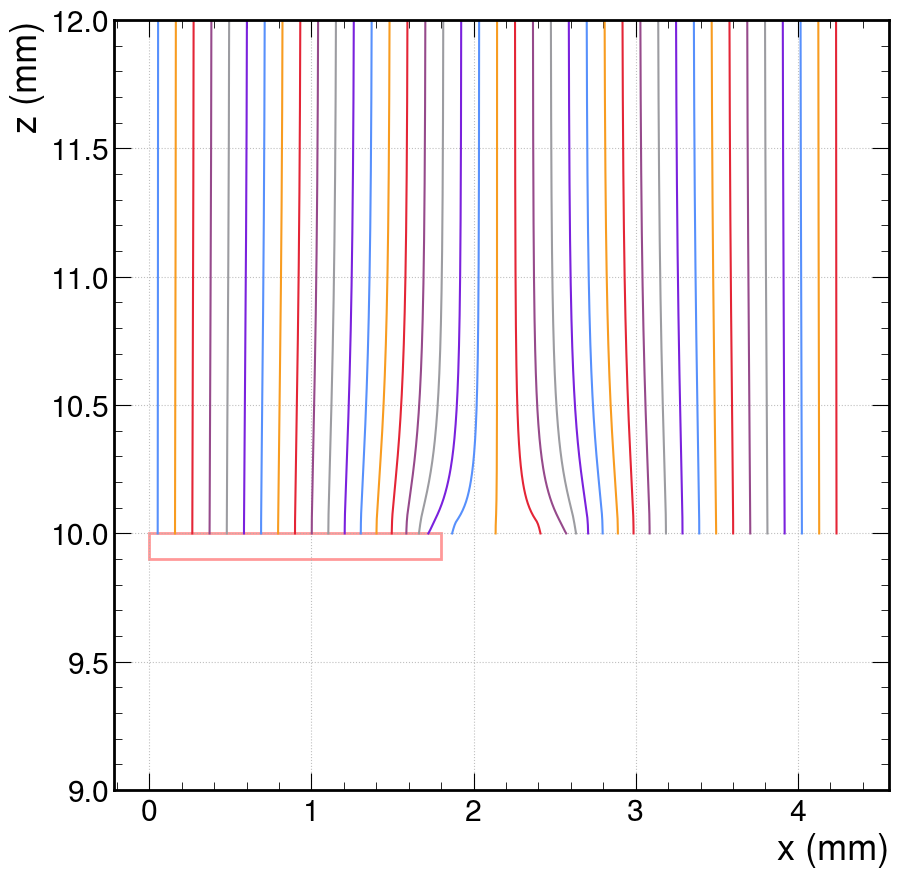

In [3]:
paths_near = np.load('/'.join([path_to_data, '/paths/drift3d_tight.npz']))['drift3d_tight'].reshape(40,40, 9000, 3)
print(f'paths_near shape: {paths_near.shape}')
fig, ax = plt.subplots()
for i in range(40):
    ax.plot(11-11+paths_near[i, 18, :,0], paths_near[i,18,:,2])
    # print(f'path {i} starts at x={11+paths_near[i, 19, 0,0]:.3f}, z={paths_near[i,19,0,2]:.3f} and ends at x={11+paths_near[i, 19, -1,0]:.3f}, z={paths_near[i,19,-1,2]:.3f}')
    print(f'path position in y: {paths_near[i, 18, -1, :]}')
    # ax.plot(11+paths_near[i, 19, :,0], paths_near[i,19,:,2])
# Pixel-pad x boundaries (left edge, right edge pairs), extracted from the drift
# boundary at z-cell 100 (= pad plane z=10.0 mm) in
# store_validate_neumann_fulldepth_01mm/boundary/drift_full.npz.
#
# The 4.4 mm-pitch tile is centred on the 0.6 mm inter-pixel GAP, so the single
# 3.8 mm rounded-square pad (chamfer_r 0.4 mm) appears as TWO x-segments with the
# gap cross running through the tile centre.  Away from the chamfer the pad metal
# occupies nodes x=0.0..1.8 mm and x=2.5..4.3 mm (physical gap edges 1.85 & 2.45
# mm = 0.6 mm; the chamfer widens the gap to ~1.75/2.55 mm at the pad corners
# y=1.8/2.5 mm).
pixel_pads = [
    (0.0, 1.85),    # left pad segment  (metal nodes x=0.0..1.8 mm)
    (2.45, 4.4),    # right pad segment (metal nodes x=2.5..4.3 mm, wraps at 4.4)
]
# NOTE: the loop below slices at y-launch-index 18 (y~=2.04 mm), which falls
# INSIDE the gap band (y-cells 19-24) -> there is NO pad metal at that y.  Pick a
# y-index over the pad (e.g. 0-16 or 26-39) to see paths landing on the pad.

z_bottom = 10.0-0.1#-0.05
z_top = 10.1-0.1

for (x_left, x_right) in pixel_pads:
    rect = patches.Rectangle(
        (x_left, z_bottom),
        x_right - x_left,
        z_top - z_bottom,
        linewidth=2,
        edgecolor='red',
        facecolor='white',
        alpha=0.4
    )
    ax.add_patch(rect)
ax.set_ylim(9., 12)
ax.set_xlabel('x (mm)')
ax.set_ylabel('z (mm)')
plt.grid()

In [ ]:
# ---------------------------------------------------------------------------
# E-field at the endpoints of paths that STOP ON THE FR4 SURFACE but NOT on pad
# metal (pochoir-49u1).  Self-contained: loads the 0.01us backup directly (the
# top-level paths/ key is absent in this store).
#
# The no-flux FR4 insulator is a continuous full plane at z=9.9 mm, so every
# drifting electron terminates at the FR4 top face z=10.0 mm (endtag 2 = SURFACE);
# none reach a separate pad-metal cell (endtag 1 is absent).  A path lands "on pad
# metal" if its (x,y) endpoint sits over a pad cell at z-cell 100, else it lands
# on bare FR4 surface (over the gap).
_p    = np.load('/'.join([path_to_data, 'bckup_0.01us/paths/drift3d_tight.npz']))['drift3d_tight']          # (1600,9000,3)
_tag  = np.load('/'.join([path_to_data, 'bckup_0.01us/paths/drift3d_tight_endtag.npz']))['drift3d_tight_endtag']
_efld = np.load('/'.join([path_to_data, 'bckup_0.01us/velocity/efield.npz']))['efield']                     # (3,44,44,601)
_bnd  = np.load('/'.join([path_to_data, 'boundary/drift_full.npz']))['drift_full']
_phi  = np.load('/'.join([path_to_data, 'potential/drift3d.npz']))['drift3d']
_sp, _nx = 0.1, 44
_K = abs((_phi[10,10,300]-_phi[10,10,400])/10.) / abs(_efld[2,10,10,300])   # stored -> V/mm (=1e6); bulk |E|=49.94 V/mm
_ends = _p[:,-1,:]
_ix = (np.round(_ends[:,0]/_sp).astype(int)) % _nx
_iy = (np.round(_ends[:,1]/_sp).astype(int)) % _nx
_surf   = _tag == 2
_on_pad = _bnd[_ix,_iy,100] != 0
_gap    = _surf & (~_on_pad)                    # FR4-surface, NOT on pad metal
_E = np.stack([_efld[0,_ix,_iy,100], _efld[1,_ix,_iy,100], _efld[2,_ix,_iy,100]]) * _K   # V/mm
_mag = np.sqrt((_E**2).sum(0)); _Ez = _E[2]; _Et = np.sqrt(_E[0]**2+_E[1]**2)
print(f'surface-ending paths: {int(_surf.sum())}  (on pad metal: {int(_on_pad[_surf].sum())}, on bare FR4/gap: {int(_gap.sum())})')
print(f'E-field at the {int(_gap.sum())} FR4-surface (gap) endpoints [V/mm]:')
print(f'  |E|    mean {_mag[_gap].mean():.1f}  min {_mag[_gap].min():.1f}  max {_mag[_gap].max():.1f}')
print(f'  Ez     mean {_Ez[_gap].mean():.1f}   (bulk drift field -49.94 V/mm)')
print(f'  Etrans mean {_Et[_gap].mean():.1f}  max {_Et[_gap].max():.1f}')
print(f'  => |E| enhanced {_mag[_gap].mean()/49.94:.2f}x above bulk (field focuses toward the pad edges).')
print(f'  (paths over pad metal report |E|=0: velo zeroes the field inside conductor cells.)')
